# Notebook 07 — Model EDA

Exploratory analysis of the final modeling dataset to understand target distribution, feature correlations, and multicollinearity.

**Reads:** `final_dataset.parquet`  
**Writes:** `figures/` only


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

weekly = pd.read_parquet(PROCESSED_DIR / "final_dataset.parquet")
print(f"Dataset: {len(weekly)} rows \u00d7 {len(weekly.columns)} columns")
weekly.head()

Dataset: 5016 rows × 67 columns


,week_start,region,stranding_count,temperature_2m_max_0_days_prior_mean,temperature_2m_max_0_days_prior_max,temperature_2m_min_0_days_prior_mean,moon_age_mean,temp_delta_day0_mean,temp_7day_mean_max_mean,temp_7day_max_max_mean,...,region_R10,region_R11,region_R2,region_R3,region_R4,region_R5,region_R6,region_R7,region_R8,region_R9
0,2017-01-02,R0,0,20.8,20.8,14.4,NaN,4.4,16.228571,21.50,...,False,False,False,False,False,False,False,False,False,False
1,2017-01-09,R0,0,20.8,20.8,14.4,NaN,4.4,16.228571,21.50,...,False,False,False,False,False,False,False,False,False,False
2,2017-01-16,R0,2,19.8,20.5,15.1,22.132944,-1.4,20.835714,22.95,...,False,False,False,False,False,False,False,False,False,False
3,2017-01-23,R0,0,19.8,20.5,15.1,NaN,-1.4,20.835714,22.95,...,False,False,False,False,False,False,False,False,False,False
4,2017-01-30,R0,1,20.1,20.1,11.1,5.102356,0.0,15.085714,20.10,...,False,False,False,False,False,False,False,False,False,False


## Target Distribution


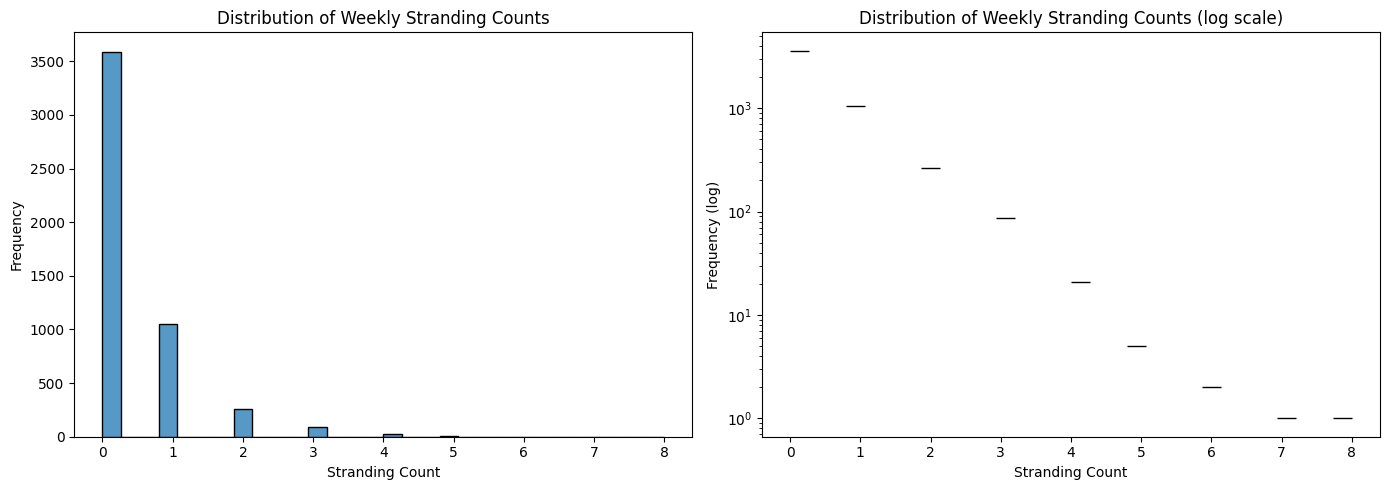

Mean: 0.39
Median: 0
Max: 8
Zero-count weeks: 3590 (71.6%)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(weekly["stranding_count"], bins=30, kde=False, ax=axes[0])
axes[0].set_title("Distribution of Weekly Stranding Counts")
axes[0].set_xlabel("Stranding Count")
axes[0].set_ylabel("Frequency")

sns.histplot(
    weekly["stranding_count"], bins=30, kde=False, ax=axes[1], log_scale=(False, True)
)
axes[1].set_title("Distribution of Weekly Stranding Counts (log scale)")
axes[1].set_xlabel("Stranding Count")
axes[1].set_ylabel("Frequency (log)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean: {weekly['stranding_count'].mean():.2f}")
print(f"Median: {weekly['stranding_count'].median():.0f}")
print(f"Max: {weekly['stranding_count'].max()}")
print(
    f"Zero-count weeks: {(weekly['stranding_count'] == 0).sum()} ({(weekly['stranding_count'] == 0).mean():.1%})"
)

## Target by Region


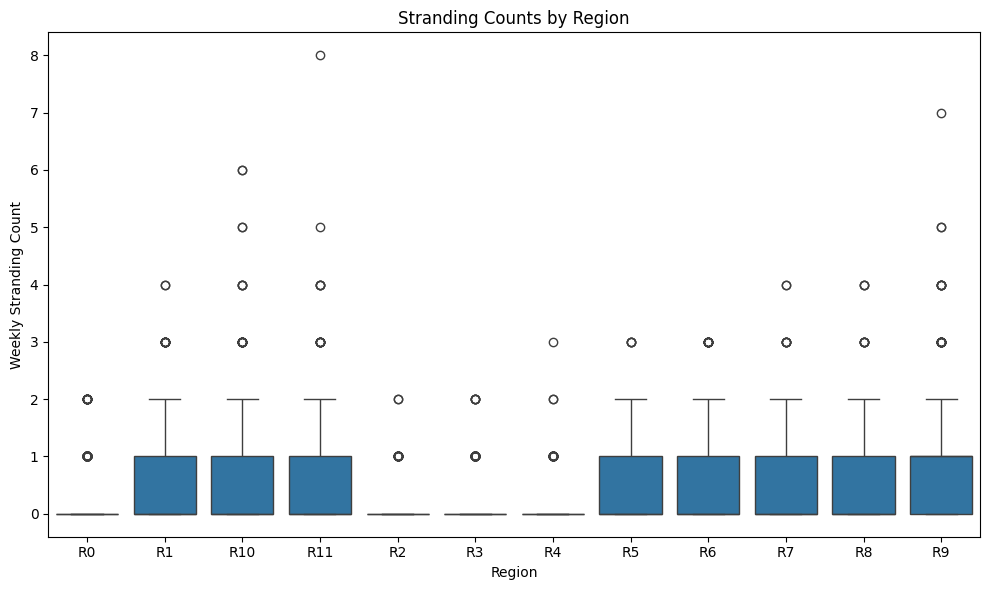

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=weekly, x="region", y="stranding_count", ax=ax)
ax.set_title("Stranding Counts by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Weekly Stranding Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

## Time Series by Region


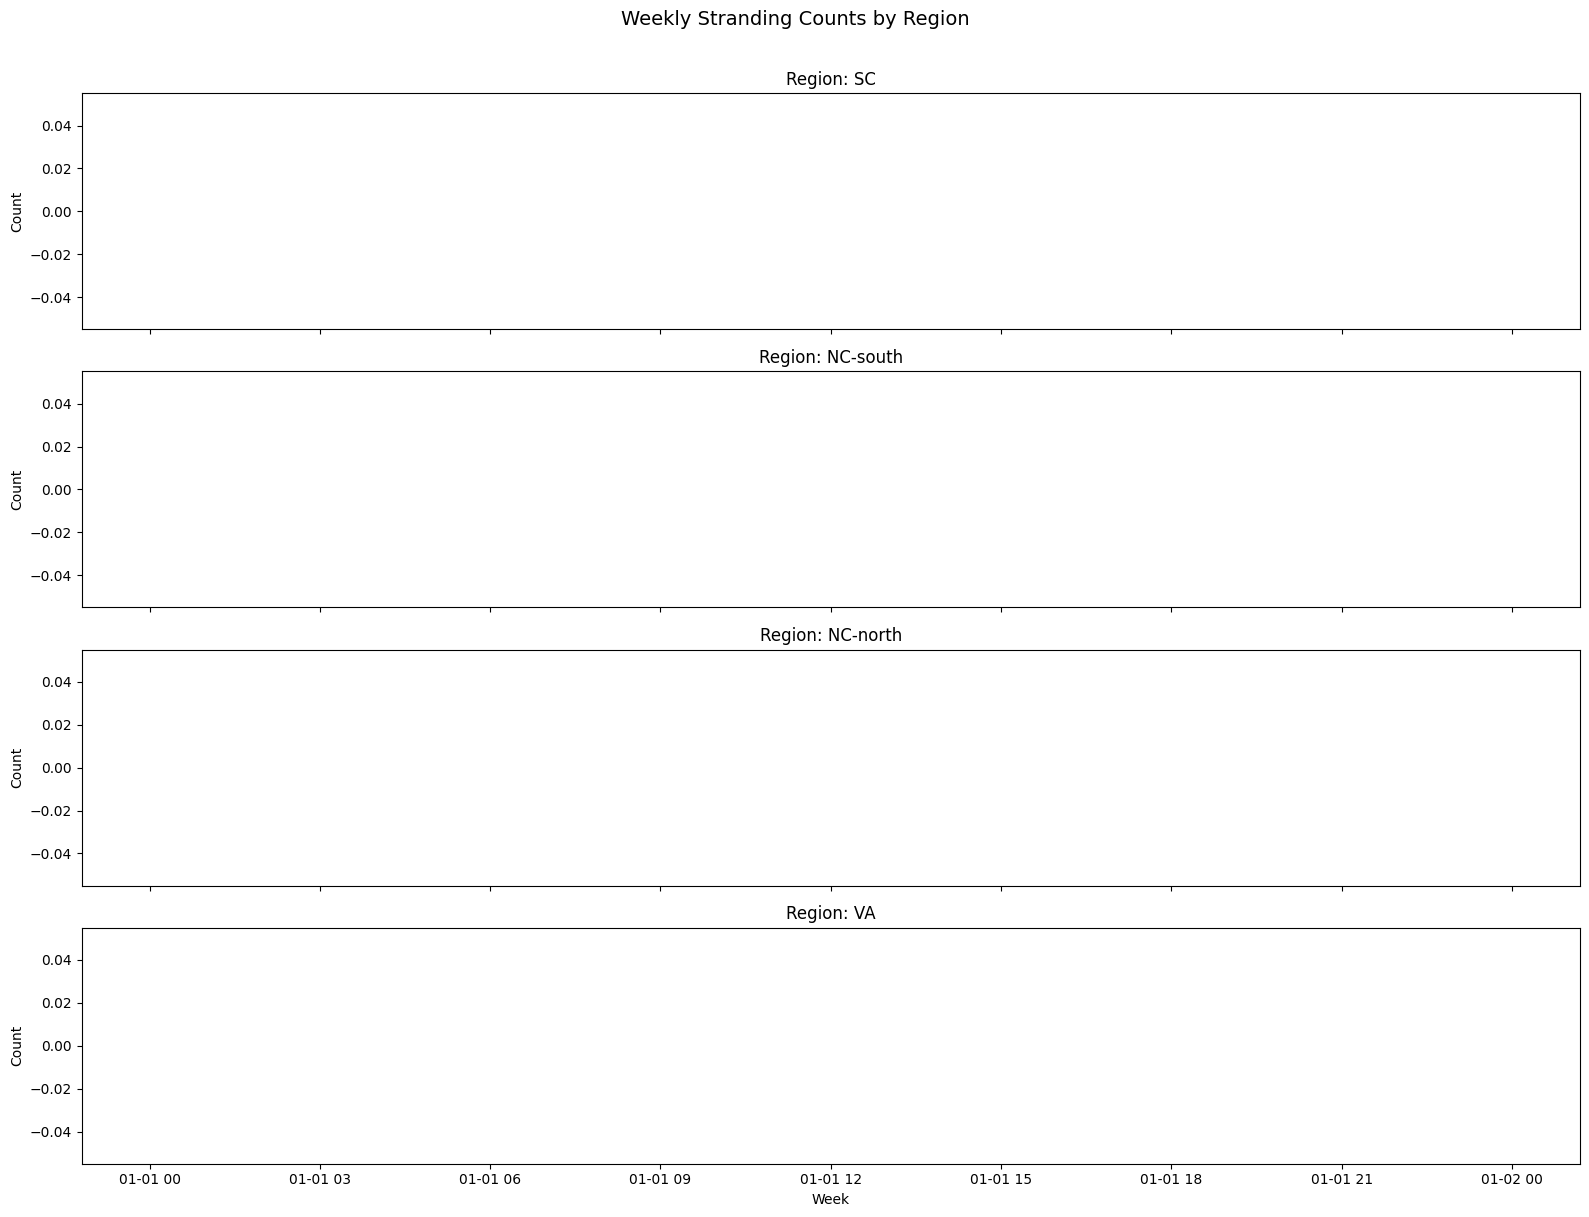

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
regions = ["SC", "NC-south", "NC-north", "VA"]

for ax, region in zip(axes, regions):
    region_data = weekly[weekly["region"] == region].sort_values("week_start")
    ax.plot(
        region_data["week_start"],
        region_data["stranding_count"],
        linewidth=0.7,
        alpha=0.8,
    )
    ax.set_title(f"Region: {region}")
    ax.set_ylabel("Count")

axes[-1].set_xlabel("Week")
fig.suptitle("Weekly Stranding Counts by Region", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "time_series_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

## Seasonal Pattern (Month-of-Year Aggregates)


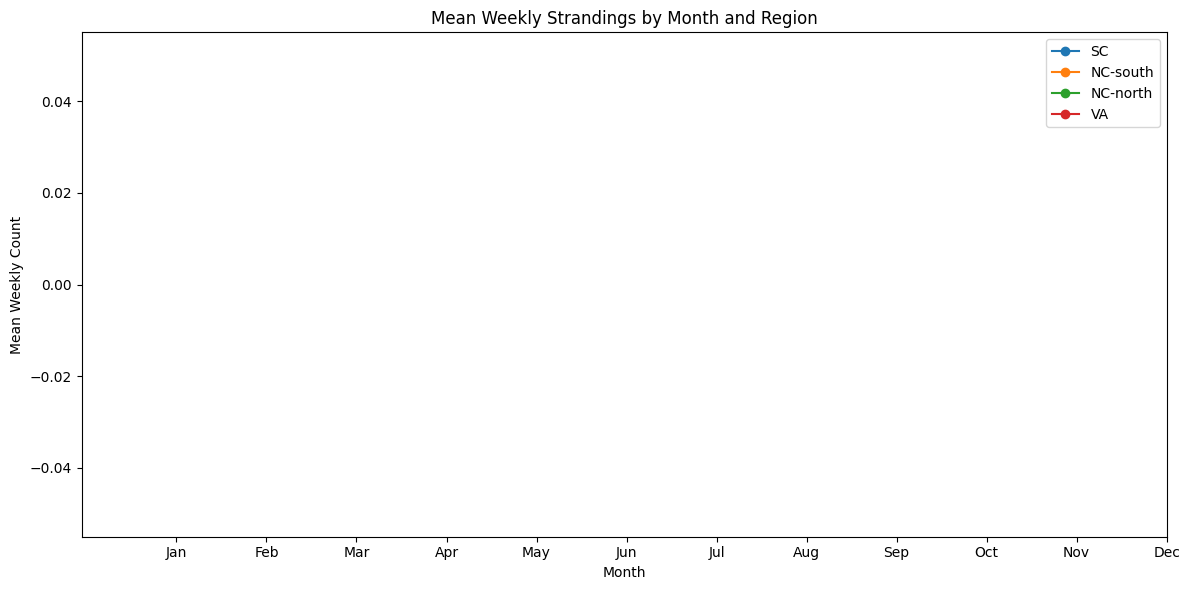

In [5]:
weekly["month"] = weekly["week_start"].dt.month
monthly_avg = (
    weekly.groupby(["month", "region"])["stranding_count"].mean().reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
for region in ["SC", "NC-south", "NC-north", "VA"]:
    region_data = monthly_avg[monthly_avg["region"] == region]
    ax.plot(
        region_data["month"], region_data["stranding_count"], marker="o", label=region
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
ax.set_title("Mean Weekly Strandings by Month and Region")
ax.set_xlabel("Month")
ax.set_ylabel("Mean Weekly Count")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "seasonal_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

## Feature Correlation with Target


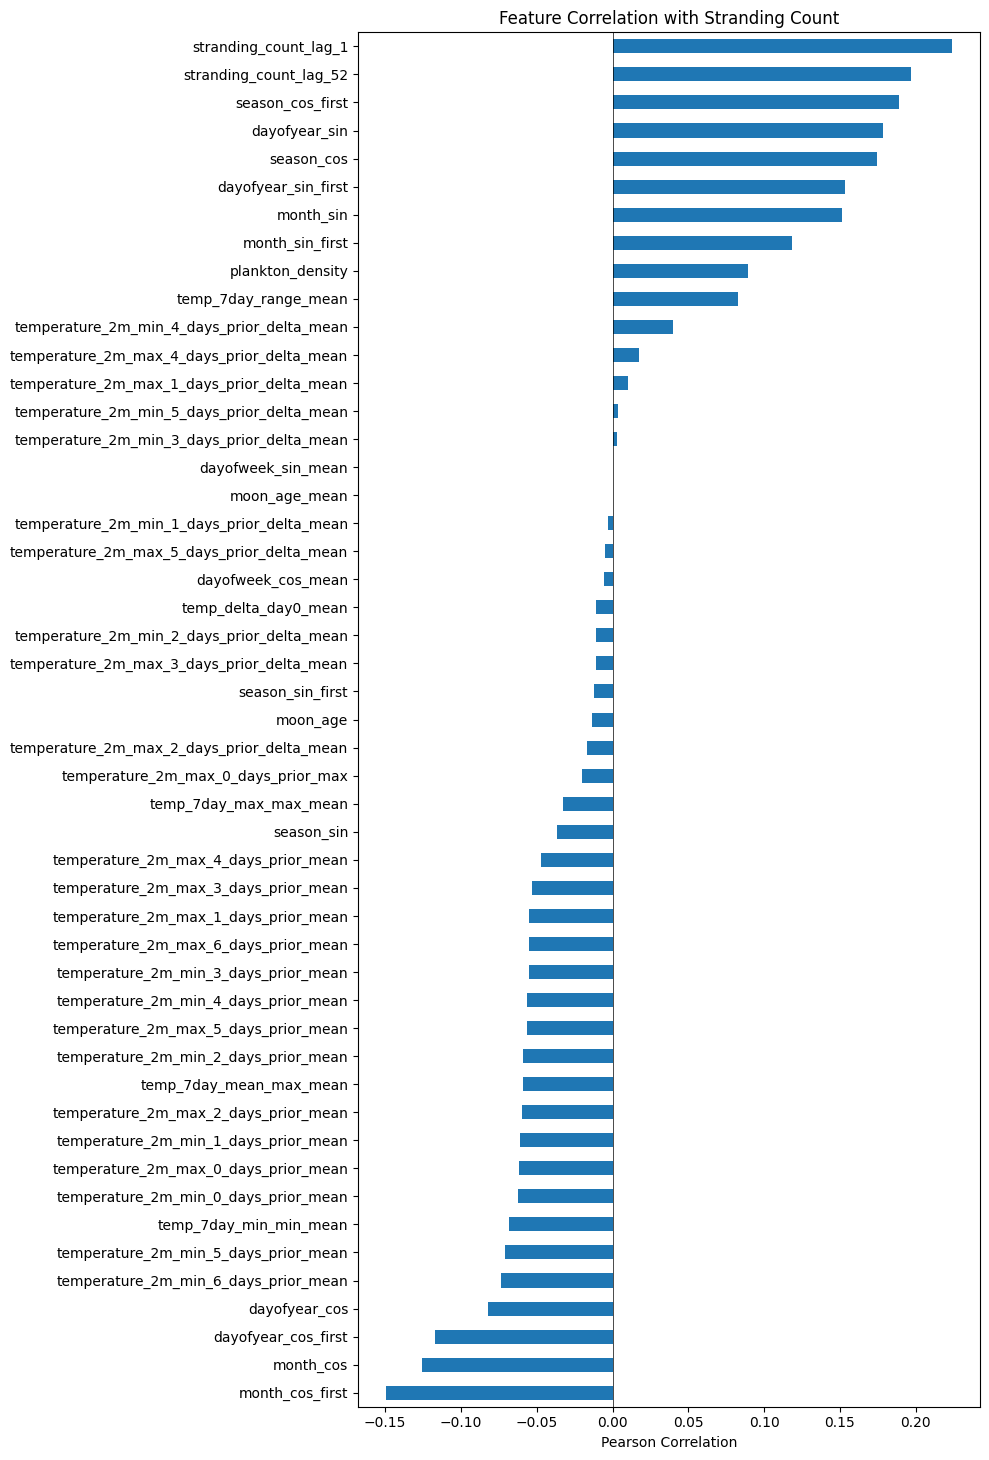

In [6]:
feature_cols = [
    c
    for c in weekly.columns
    if c not in ["week_start", "region", "stranding_count", "moon_phase", "month"]
    and weekly[c].dtype in ["float64", "float32", "int64", "int32"]
]

correlations = weekly[feature_cols].corrwith(weekly["stranding_count"]).sort_values()

fig, ax = plt.subplots(figsize=(10, max(6, len(correlations) * 0.3)))
correlations.plot(kind="barh", ax=ax)
ax.set_title("Feature Correlation with Stranding Count")
ax.set_xlabel("Pearson Correlation")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## Feature Correlation Heatmap

Flag pairs with |r| > 0.85 as multicollinearity candidates.


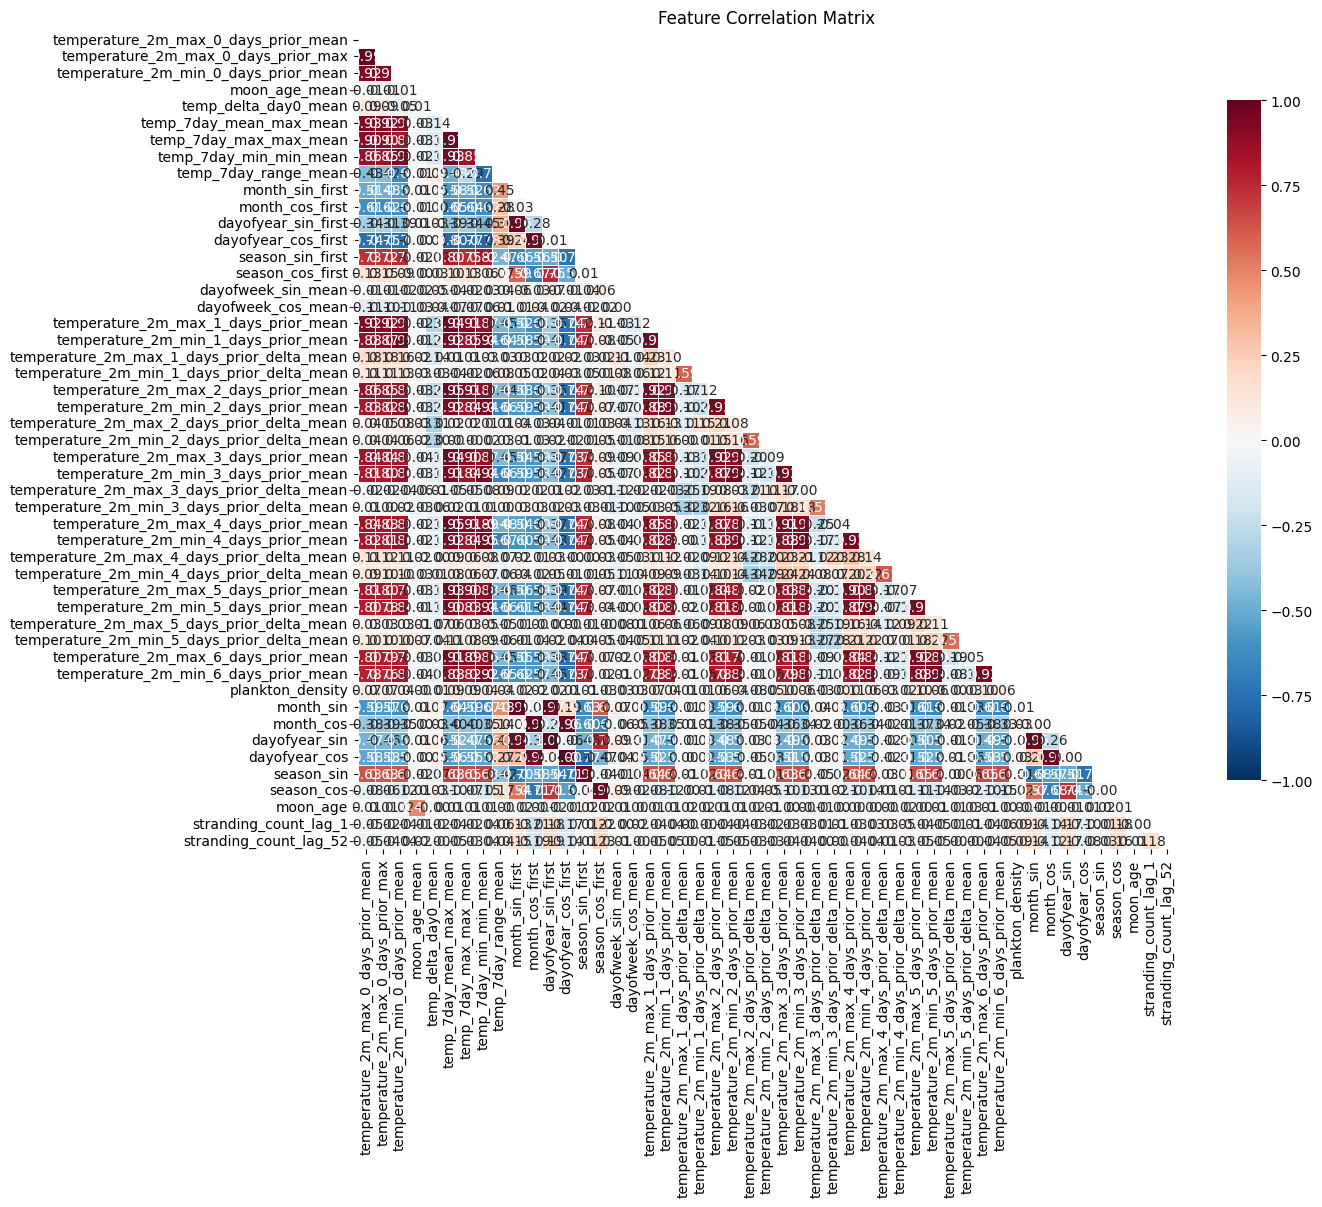

Highly correlated feature pairs (|r| > 0.85):
  temperature_2m_max_0_days_prior_mean <-> temperature_2m_max_0_days_prior_max: r=0.992
  temperature_2m_max_0_days_prior_mean <-> temperature_2m_min_0_days_prior_mean: r=0.925
  temperature_2m_max_0_days_prior_mean <-> temp_7day_mean_max_mean: r=0.927
  temperature_2m_max_0_days_prior_mean <-> temp_7day_max_max_mean: r=0.900
  temperature_2m_max_0_days_prior_mean <-> temp_7day_min_min_mean: r=0.859
  temperature_2m_max_0_days_prior_mean <-> temperature_2m_max_1_days_prior_mean: r=0.925
  temperature_2m_max_0_days_prior_mean <-> temperature_2m_min_1_days_prior_mean: r=0.878
  temperature_2m_max_0_days_prior_mean <-> temperature_2m_max_2_days_prior_mean: r=0.862
  temperature_2m_max_0_days_prior_max <-> temperature_2m_min_0_days_prior_mean: r=0.916
  temperature_2m_max_0_days_prior_max <-> temp_7day_mean_max_mean: r=0.918
  temperature_2m_max_0_days_prior_max <-> temp_7day_max_max_mean: r=0.895
  temperature_2m_max_0_days_prior_max <-> temp_

In [7]:
corr_matrix = weekly[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag highly correlated pairs
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            )

if high_corr:
    print("Highly correlated feature pairs (|r| > 0.85):")
    for f1, f2, r in high_corr:
        print(f"  {f1} <-> {f2}: r={r:.3f}")
else:
    print("No feature pairs with |r| > 0.85")

## Missing Value Audit


Columns with missing values:
  moon_age_mean: 3590 (71.6%)
  month_sin_first: 3590 (71.6%)
  month_cos_first: 3590 (71.6%)
  dayofyear_sin_first: 3590 (71.6%)
  dayofyear_cos_first: 3590 (71.6%)
  season_sin_first: 3590 (71.6%)
  season_cos_first: 3590 (71.6%)
  plankton_density: 1254 (25.0%)


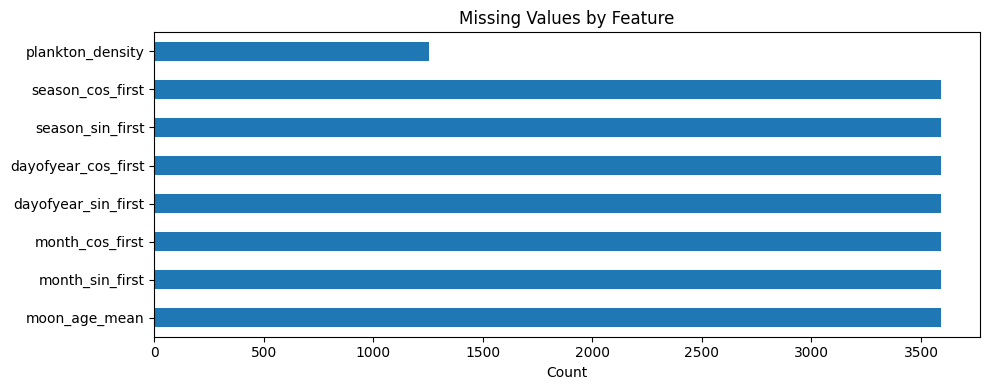

In [8]:
missing = weekly[feature_cols + ["stranding_count"]].isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print("Columns with missing values:")
    for col, count in missing.items():
        print(f"  {col}: {count} ({count / len(weekly):.1%})")

    fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.4)))
    missing.plot(kind="barh", ax=ax)
    ax.set_title("Missing Values by Feature")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "missing_values.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No missing values in feature columns!")

## Key Decisions

After reviewing the above:

- If any two weather features have |r| > 0.85, keep only one in the model. Prefer `temperature_2m_max_0_days_prior_mean` as the primary temperature signal.
- Confirm that the target distribution is right-skewed / Poisson-like — this validates using Poisson objective in LightGBM.
